In [8]:
# ==========================================
# 1) Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [9]:
# ==========================================
# 2) โหลดข้อมูล
# ==========================================
df = pd.read_csv("output3.csv")  


In [10]:
# ==========================================
# 3) ตรวจคุณภาพข้อมูล (Data Quality Check)
# ==========================================
# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicate records
print("Duplicate rows:", df.duplicated().sum())

# Data types
print("Data types:\n", df.dtypes)

# สถิติเบื้องต้น
print("Summary statistics:\n", df.describe())

Missing values:
 SEX          0
AGE          0
Injp         0
Risk1        0
Risk2        0
Risk4        0
Risk5        0
Ais1         0
Ais2         0
Ais3         0
Ais4         0
Ais5         0
Ais6         0
GCS          0
SBP          0
RR           0
PR           0
Time         0
Dead         0
ISS          0
RTS          0
SBP_group    0
RR_group     0
dtype: int64
Duplicate rows: 0
Data types:
 SEX            int64
AGE            int64
Injp           int64
Risk1          int64
Risk2          int64
Risk4          int64
Risk5          int64
Ais1           int64
Ais2           int64
Ais3           int64
Ais4           int64
Ais5           int64
Ais6           int64
GCS            int64
SBP            int64
RR             int64
PR             int64
Time         float64
Dead           int64
ISS            int64
RTS          float64
SBP_group      int64
RR_group       int64
dtype: object
Summary statistics:
                SEX          AGE         Injp        Risk1        Risk2  \
co

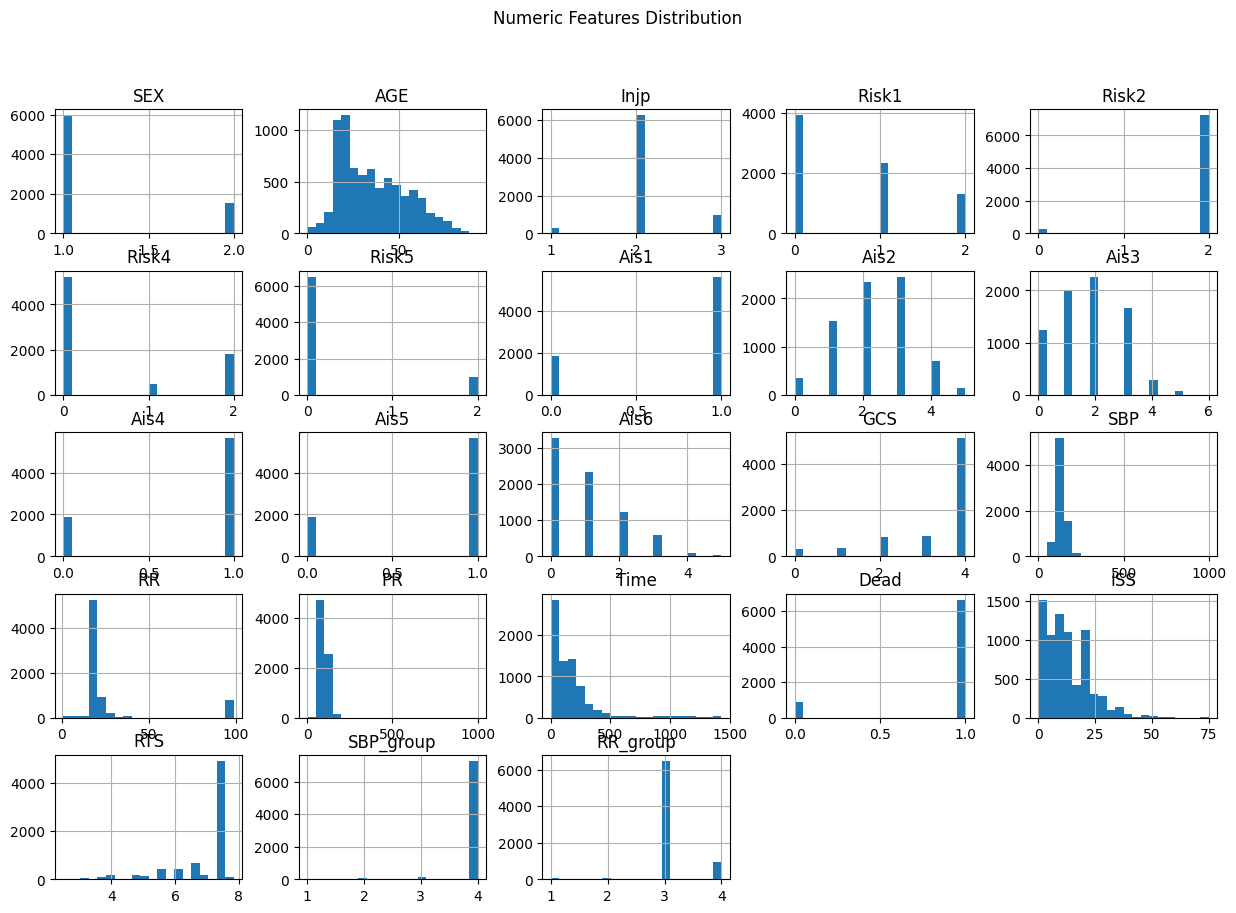

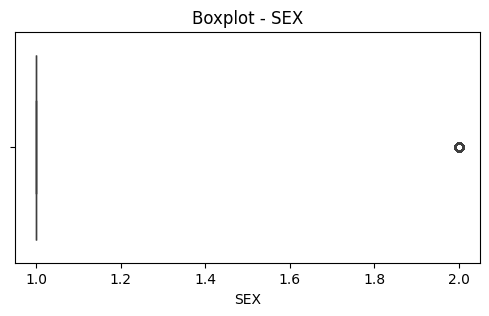

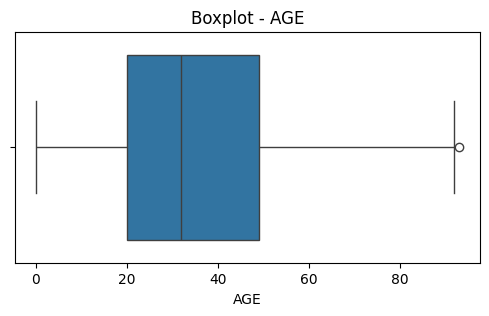

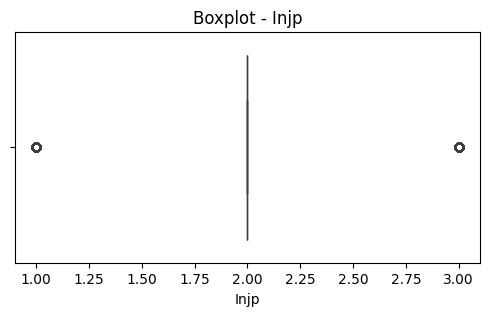

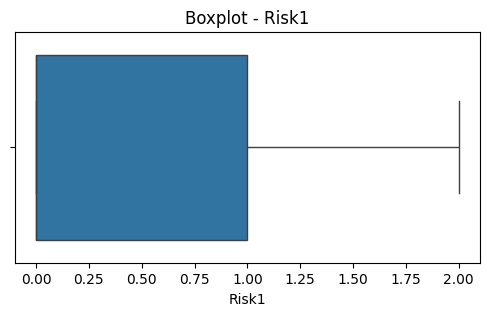

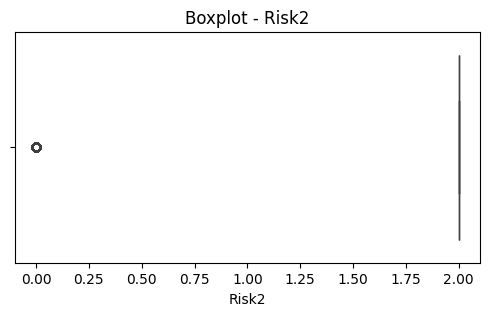

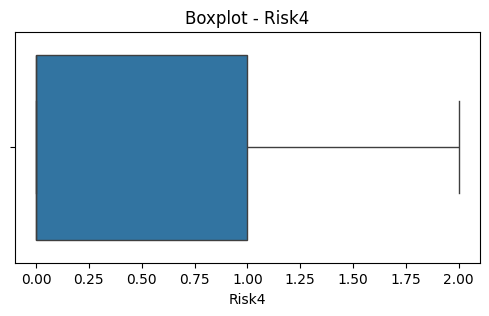

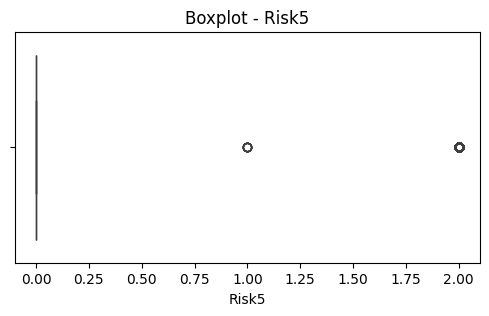

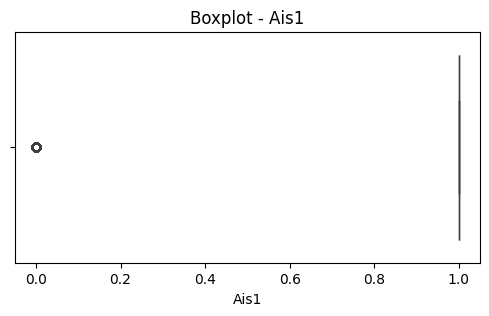

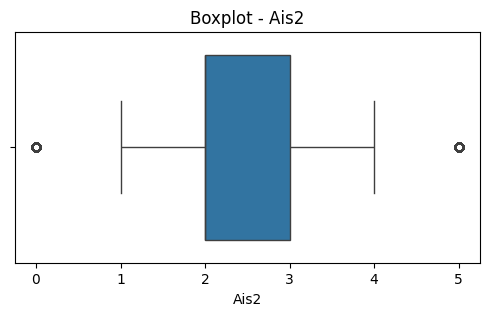

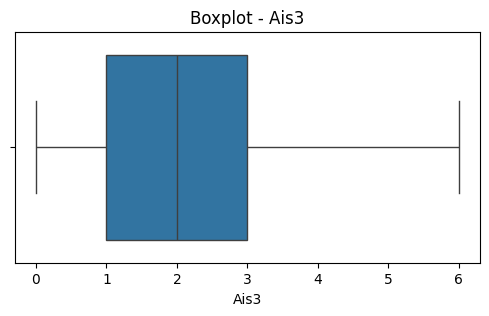

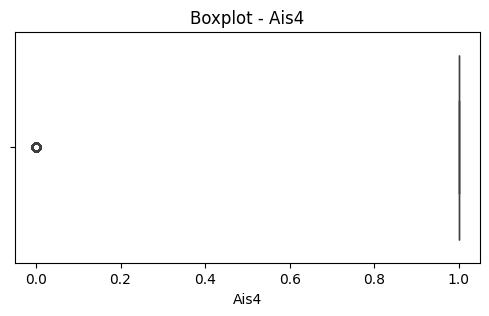

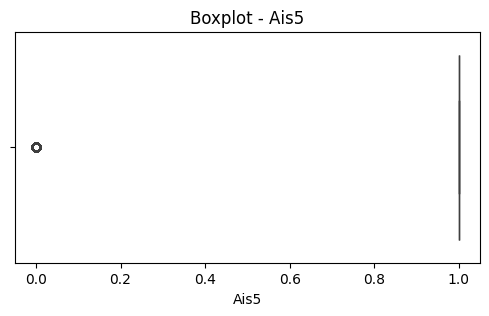

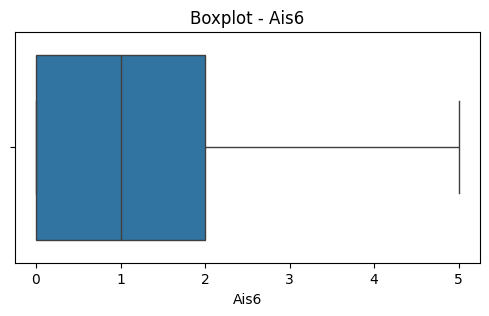

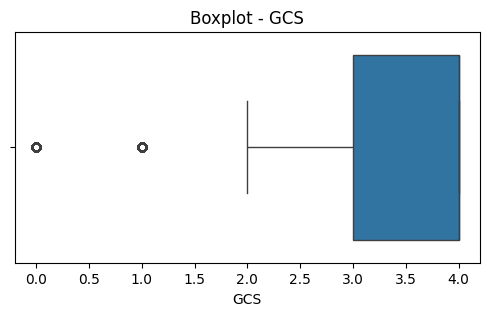

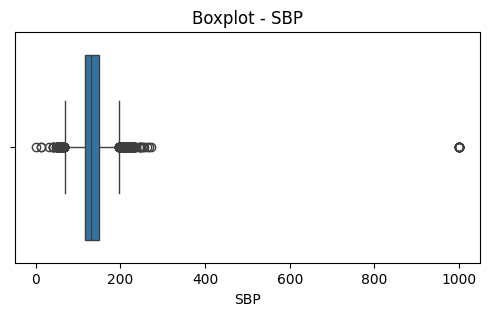

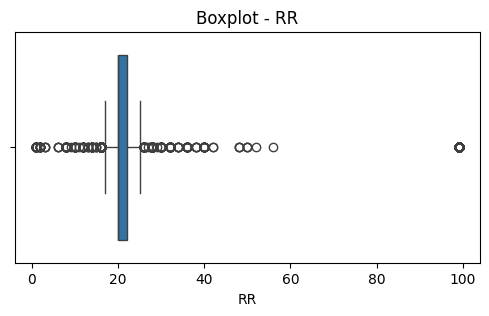

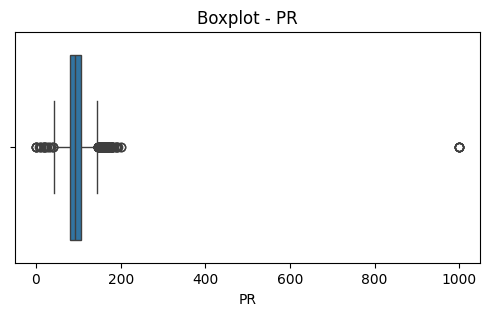

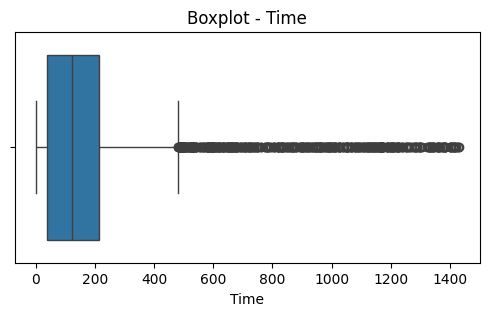

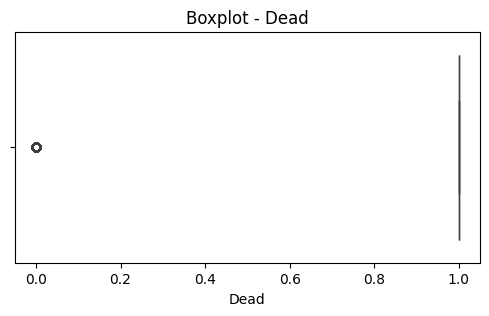

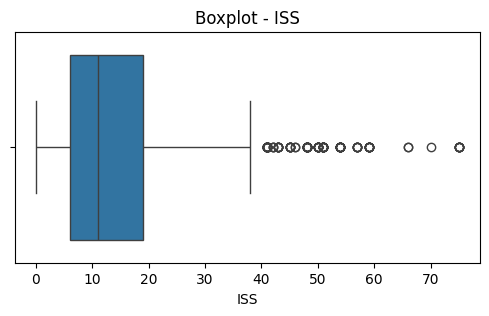

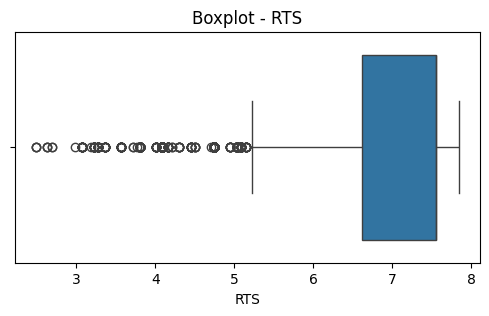

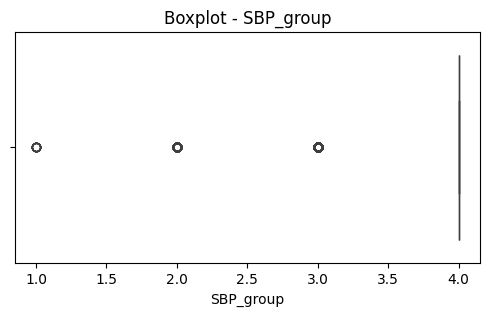

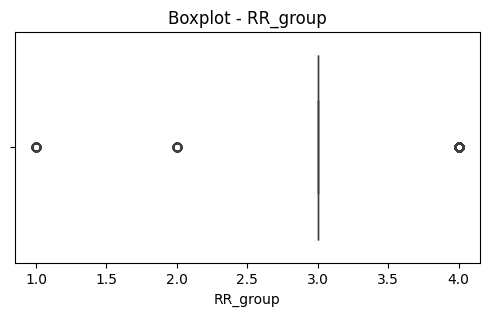

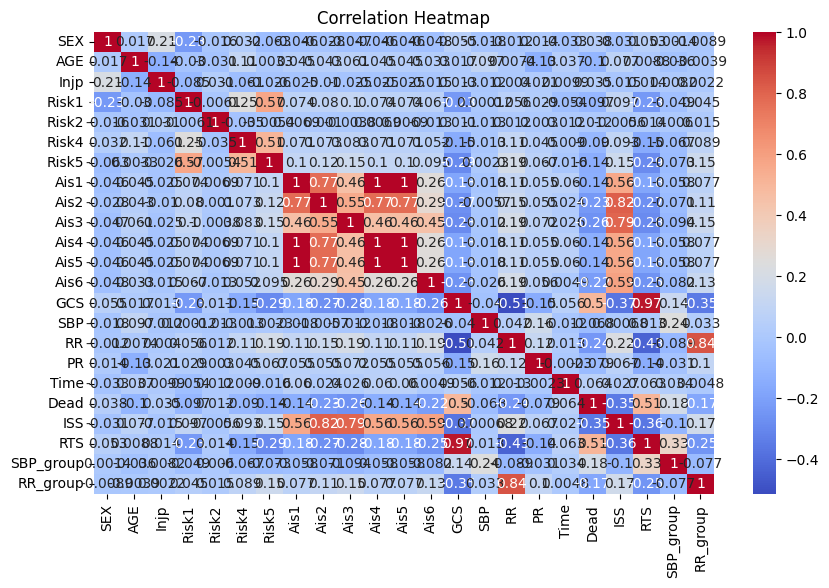

In [11]:
# ==========================================
# 4) สำรวจข้อมูลเบื้องต้น (EDA)
# ==========================================

# 4.1 การกระจายของตัวเลข
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle("Numeric Features Distribution")
plt.show()

# 4.2 Outlier Check
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# 4.3 ความสัมพันธ์ระหว่างตัวแปร
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 4.4 Class balance (ถ้าเป็น classification)
if "target" in df.columns:
    plt.figure(figsize=(5, 4))
    sns.countplot(x=df["target"])
    plt.title("Target Class Distribution")
    plt.show()



In [12]:
# ==========================================
# 5) การทดสอบสมมติฐาน (Statistical Tests)
# ==========================================

# 5.1 Normality test (Shapiro-Wilk)
for col in num_cols:
    stat, p = stats.shapiro(df[col].dropna())
    print(f"Shapiro-Wilk Test for {col}: p-value={p}")
    if p > 0.05:
        print("  => Data looks normally distributed.")
    else:
        print("  => Data is NOT normal.")

# 5.2 ความสัมพันธ์เชิงสถิติ (Pearson/Spearman)
for col in num_cols:
    if col != "target" and "target" in df.columns:
        corr, p = stats.pearsonr(df[col].dropna(), df["target"].dropna())
        print(f"Pearson correlation between {col} and target: corr={corr}, p={p}")

# 5.3 Chi-square test (สำหรับตัวแปรหมวดหมู่)
cat_cols = df.select_dtypes(exclude=np.number).columns
if "target" in df.columns:
    for col in cat_cols:
        contingency = pd.crosstab(df[col], df["target"])
        chi2, p, dof, exp = stats.chi2_contingency(contingency)
        print(f"Chi-square Test for {col}: p-value={p}")

Shapiro-Wilk Test for SEX: p-value=1.9562545168900445e-90
  => Data is NOT normal.
Shapiro-Wilk Test for AGE: p-value=1.0389982304216366e-44
  => Data is NOT normal.
Shapiro-Wilk Test for Injp: p-value=3.527998130687558e-88
  => Data is NOT normal.
Shapiro-Wilk Test for Risk1: p-value=4.533453656294965e-75
  => Data is NOT normal.
Shapiro-Wilk Test for Risk2: p-value=7.950963020818751e-102
  => Data is NOT normal.
Shapiro-Wilk Test for Risk4: p-value=3.961794508317328e-85
  => Data is NOT normal.
Shapiro-Wilk Test for Risk5: p-value=2.2137271534761305e-94
  => Data is NOT normal.
Shapiro-Wilk Test for Ais1: p-value=1.9556223600552339e-88
  => Data is NOT normal.
Shapiro-Wilk Test for Ais2: p-value=8.075665410594017e-52
  => Data is NOT normal.
Shapiro-Wilk Test for Ais3: p-value=1.0485173625931088e-53
  => Data is NOT normal.
Shapiro-Wilk Test for Ais4: p-value=1.9556223600552339e-88
  => Data is NOT normal.
Shapiro-Wilk Test for Ais5: p-value=1.9556223600552339e-88
  => Data is NOT no

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7525.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
# ==========================================
# 6) ตรวจ Multicollinearity (VIF)
# ==========================================
if len(num_cols) > 1:
    X = df[num_cols].dropna()
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    print(vif_data)

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


      Feature           VIF
0         SEX  1.096460e+01
1         AGE  5.131194e+00
2        Injp  2.881954e+01
3       Risk1  2.783173e+00
4       Risk2  2.434311e+01
5       Risk4  1.946534e+00
6       Risk5  2.267755e+00
7        Ais1           inf
8        Ais2  4.245325e+01
9        Ais3  1.102635e+01
10       Ais4           inf
11       Ais5           inf
12       Ais6  3.645884e+00
13        GCS  3.417816e+06
14        SBP  1.005187e+01
15         RR  8.592276e+00
16         PR  8.708730e+00
17       Time  1.657925e+00
18       Dead  1.246616e+01
19        ISS  3.025693e+01
20        RTS  1.538086e+07
21  SBP_group  2.631162e+06
22   RR_group  2.589255e+05


In [14]:
# ==========================================
# 7) การปรับสเกล (Scaling)
# ==========================================
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)
print("Scaled Data:\n", df_scaled.head())


Scaled Data:
         SEX       AGE      Injp     Risk1     Risk2     Risk4     Risk5  \
0  1.962577  0.899146  2.262077  1.785283  0.201996  1.706694  2.533991   
1 -0.509534 -0.032911 -0.236034  0.461189 -4.950603 -0.638608 -0.395535   
2 -0.509534 -1.019795 -0.236034 -0.862905  0.201996 -0.638608 -0.395535   
3 -0.509534 -0.636006 -0.236034  0.461189 -4.950603  1.706694  2.533991   
4 -0.509534 -0.855314 -0.236034  0.461189 -4.950603 -0.638608 -0.395535   

       Ais1      Ais2      Ais3  ...       GCS       SBP        RR        PR  \
0  0.576685  0.662885  0.227489  ... -0.316868 -0.212180 -0.347489  0.856943   
1  0.576685  0.662885  0.227489  ...  0.587696  0.764253 -0.347489 -1.151432   
2  0.576685 -0.253728  1.094689  ... -0.316868  0.099447 -0.347489  0.489212   
3  0.576685 -0.253728 -0.639711  ...  0.587696 -0.960086 -0.430058  1.139812   
4 -1.734048 -1.170342 -0.639711  ... -1.221432  0.411075 -0.017211  1.139812   

       Time      Dead       ISS       RTS  SBP_group  

In [15]:
# ==========================================
# 8) การจัดการ Outliers (ตัวอย่างด้วย IQR)
# ==========================================
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Data after outlier removal:", df.shape)

Data after outlier removal: (1986, 23)


In [16]:
# ==========================================
# 9) สรุปผลการตรวจสอบ (สำหรับรายงาน)
# ==========================================
print("Final dataset shape:", df.shape)
print("Columns used:", df.columns.tolist())

Final dataset shape: (1986, 23)
Columns used: ['SEX', 'AGE', 'Injp', 'Risk1', 'Risk2', 'Risk4', 'Risk5', 'Ais1', 'Ais2', 'Ais3', 'Ais4', 'Ais5', 'Ais6', 'GCS', 'SBP', 'RR', 'PR', 'Time', 'Dead', 'ISS', 'RTS', 'SBP_group', 'RR_group']
